# <span style="color:red">  Monthly Data - EBC creation, FMB Quantiles (1970 -2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Raw returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc    = full_merged_df["EBC"]
cw_ebc = full_merged_df["CW"] - full_merged_df["EBC"]  # RF cancels in the spread

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:261: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


In [5]:
full_merged_df['MKT'] = full_merged_df['MKT_RF'] + full_merged_df['RF']

# <span style="color:red"> Get rolling betas for the two focus portfolios EBC and CW - EBC </span>

#### create factor returns

In [6]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

# Convert to timestamp to match asset_returns index
ebc.index = ebc.index.to_timestamp()
cw_ebc.index = cw_ebc.index.to_timestamp()

factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()

#### get asset returns (raw, no RF subtraction)

In [7]:
asset_returns, caps_df, ff_factors = fmb_pipe.load_monthly_inputs(DATA_RAW_DIR)

#### compute rolling betas for EBc and CW-EBC

In [8]:
betas_ebc = fmb_betas.compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:34<00:00, 20.08it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


In [9]:

betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:28<00:00, 25.07it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [10]:
start_date = "1969-10-01"

## Filter all returns to match start date

In [11]:
asset_returns_trimmed = asset_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [37]:
n_q1, n_q2 = 1, 10

In [38]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

ew_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/1 [00:00<?, ?it/s]

,1,2,3,4,5,6,7,8,9,10
1,0.127618,0.121484,0.123443,0.124229,0.138954,0.136716,0.136245,0.149579,0.155808,0.155863


In [14]:

rename_map =  {
    "Q1_Q1": "High Pref",
    "Q1_Q2": "Mid Pref",
    "Q1_Q3": "Low Pref"
}

# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
ew_portrets_raw = ew_results['portrets_wide'].copy()
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)


In [39]:

# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
ew_portrets_raw = ew_results['portrets_wide'].copy()

ew_results['portrets_wide'].columns
selected_columns = ["CW",'Q1_Q1', 'Q1_Q2', 'Q1_Q3', 'Q1_Q4', 'Q1_Q5', 'Q1_Q6', 'Q1_Q7', 'Q1_Q8',
       'Q1_Q9', 'Q1_Q10']


In [16]:
selected_columns = ["CW","High Pref","Mid Pref","Low Pref"]

In [40]:
full_merged_df

,CW,EW,EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM,CW_RF,EW_RF,EBC_RF,CW-EW,CW-EBC,MKT
date,,,,,,,,,,,,,,,,
1963-07-01,-0.001821,-0.011361,0.000000,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101,-0.004521,-0.014061,-0.002700,0.009540,-0.001821,-0.0012
1963-08-01,0.053450,0.057987,0.000000,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100,0.050950,0.055487,-0.002500,-0.004537,0.053450,0.0533
1963-09-01,-0.010404,-0.019518,0.000000,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012,-0.013104,-0.022218,-0.002700,0.009115,-0.010404,-0.0130
1963-10-01,0.034792,0.026247,0.000000,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313,0.031892,0.023347,-0.002900,0.008546,0.034792,0.0283
1963-11-01,-0.004487,-0.004267,0.000000,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078,-0.007187,-0.006967,-0.002700,-0.000221,-0.004487,-0.0059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.024283,0.024943,0.030209,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481,0.019483,0.020143,0.025409,-0.000660,-0.005926,0.0209
2024-09-01,0.022583,0.023343,0.016079,0.0173,-0.0092,-0.0276,0.0020,-0.0029,0.0040,-0.0062,0.018583,0.019343,0.012079,-0.000760,0.006504,0.0213
2024-10-01,-0.008690,-0.016410,-0.016516,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300,-0.012590,-0.020310,-0.020416,0.007719,0.007826,-0.0061


In [41]:
if isinstance(full_merged_df.index, pd.PeriodIndex):
    full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

In [42]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

In [43]:
ew_complete_df

,CW,EW,EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM,...,Q1_Q1,Q1_Q2,Q1_Q3,Q1_Q4,Q1_Q5,Q1_Q6,Q1_Q7,Q1_Q8,Q1_Q9,Q1_Q10
date,,,,,,,,,,,,,,,,,,,,,
1970-01-01,-0.075398,-0.058388,-0.046343,-0.0811,0.0308,0.0317,-0.0175,0.0396,0.0060,0.0056,...,-0.086981,-0.088673,-0.071065,-0.073558,-0.050897,-0.042332,-0.029791,-0.042335,-0.028905,-0.049294
1970-02-01,0.059521,0.068592,0.066170,0.0514,-0.0257,0.0369,-0.0241,0.0287,0.0062,0.0027,...,0.057749,0.045625,0.074229,0.079086,0.080071,0.058734,0.084310,0.064429,0.079665,0.114613
1970-03-01,0.002794,0.003090,0.014315,-0.0106,-0.0242,0.0408,-0.0106,0.0442,0.0057,-0.0036,...,-0.019629,0.016875,-0.005282,0.024420,-0.001925,0.022679,0.004610,0.016535,0.019892,0.012025
1970-04-01,-0.088432,-0.108800,-0.092683,-0.1099,-0.0634,0.0614,-0.0063,0.0590,0.0050,-0.0083,...,-0.118267,-0.113242,-0.101842,-0.105781,-0.090065,-0.093295,-0.119133,-0.091864,-0.118324,-0.111842
1970-05-01,-0.054689,-0.082317,-0.066268,-0.0691,-0.0446,0.0332,-0.0129,0.0379,0.0053,-0.0266,...,-0.090580,-0.074636,-0.075812,-0.082426,-0.053807,-0.062314,-0.083598,-0.072636,-0.059057,-0.108637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.024283,0.024943,0.030209,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481,...,0.012694,0.007782,0.029250,0.046542,0.031213,0.026530,0.026198,0.026070,0.038442,0.011803
2024-09-01,0.022583,0.023343,0.016079,0.0173,-0.0092,-0.0276,0.0020,-0.0029,0.0040,-0.0062,...,0.018684,0.024491,0.007192,0.038916,0.024258,0.017801,0.037726,0.030926,0.008867,-0.004937
2024-10-01,-0.008690,-0.016410,-0.016516,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300,...,-0.020960,-0.027547,-0.026587,0.006719,-0.028482,0.009961,-0.005806,-0.021196,-0.012314,-0.043623


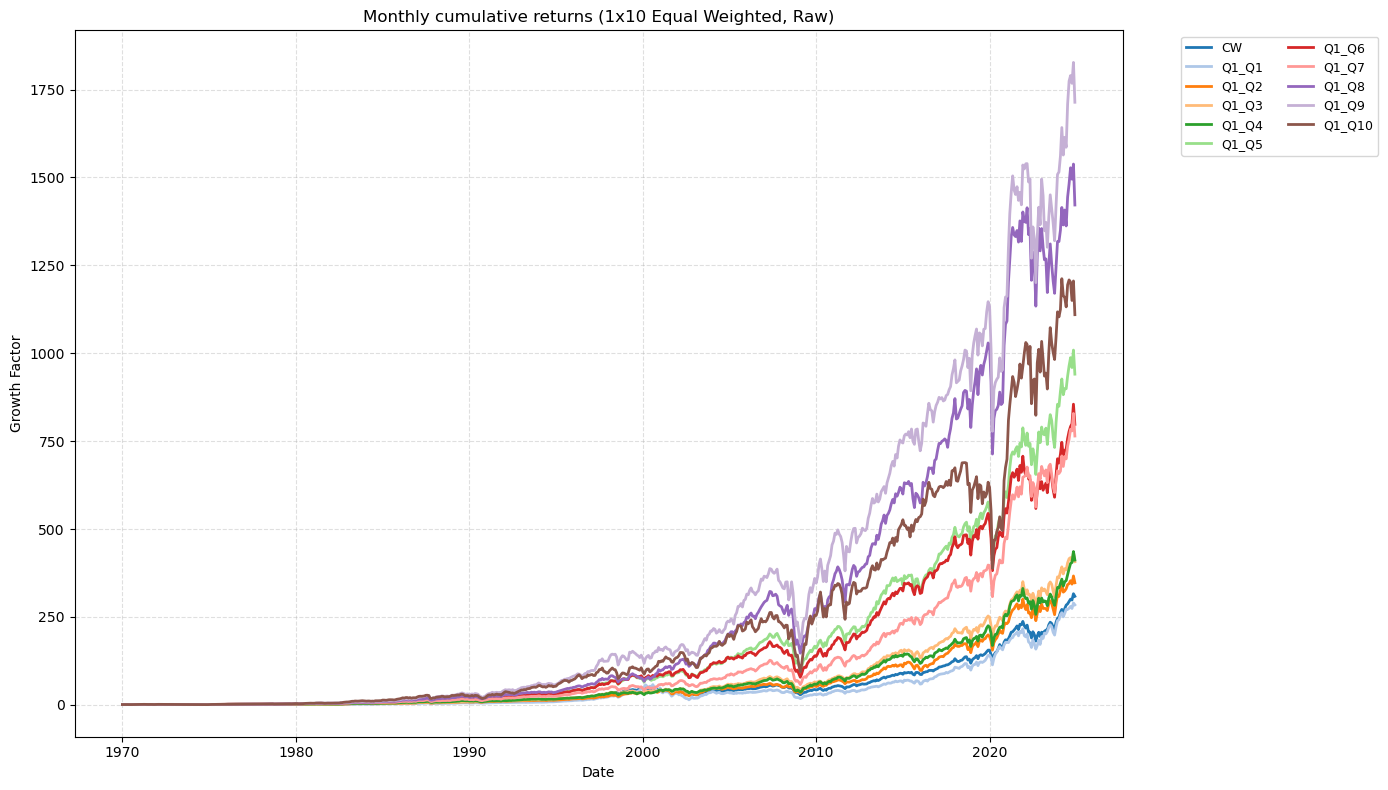

In [44]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=False)

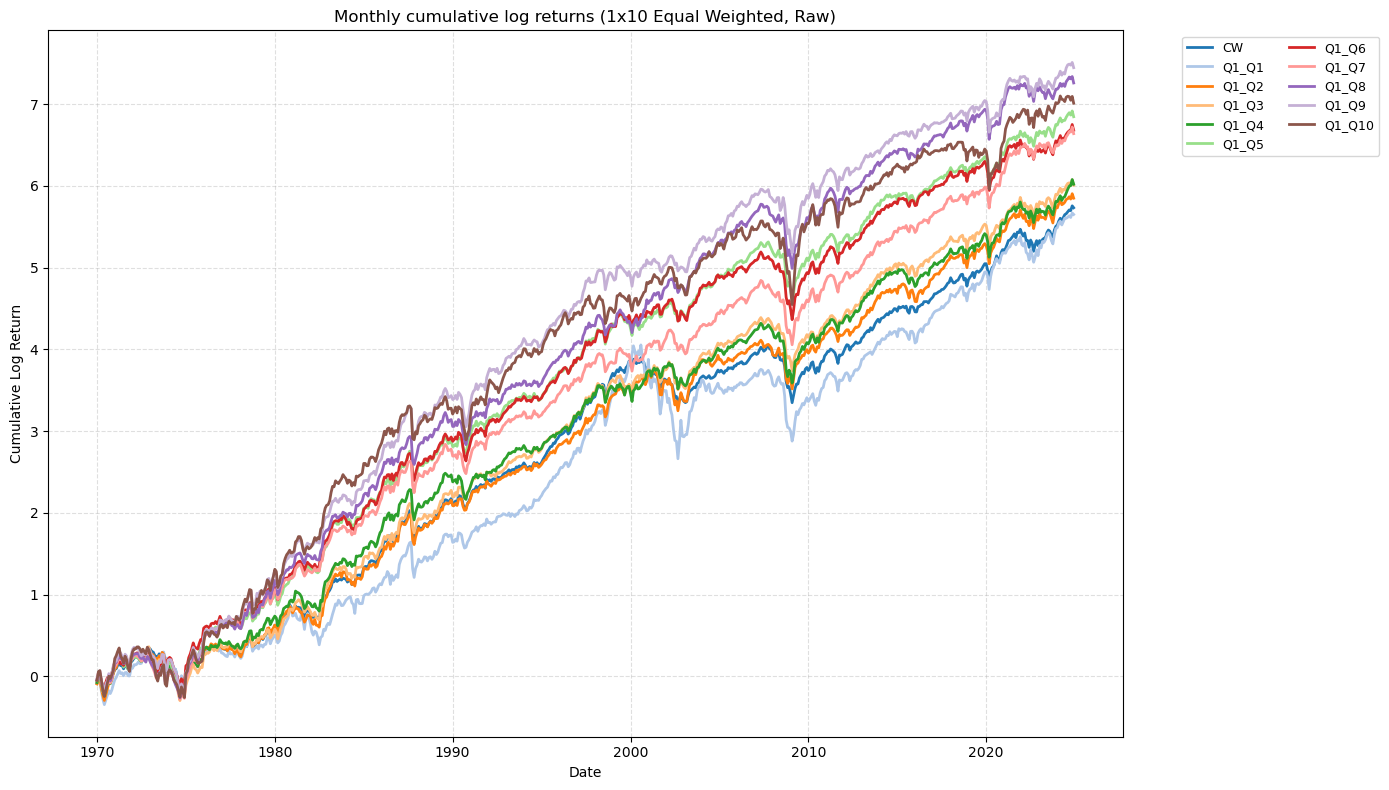

In [45]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative log returns ({n_q1}x{n_q2} Equal Weighted, Raw)",log = True)

In [46]:
monthly_ew_quantile_returns = ew_complete_df[selected_columns]

In [47]:
# Arithmetic mean grid (annualized as mean × 12)
#fmb_plots.plot_mean_grid_new(ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=False)

In [48]:
ew_portrets_raw

,Q1_Q1,Q1_Q2,Q1_Q3,Q1_Q4,Q1_Q5,Q1_Q6,Q1_Q7,Q1_Q8,Q1_Q9,Q1_Q10
date,,,,,,,,,,
1970-01-01,-0.086981,-0.088673,-0.071065,-0.073558,-0.050897,-0.042332,-0.029791,-0.042335,-0.028905,-0.049294
1970-02-01,0.057749,0.045625,0.074229,0.079086,0.080071,0.058734,0.084310,0.064429,0.079665,0.114613
1970-03-01,-0.019629,0.016875,-0.005282,0.024420,-0.001925,0.022679,0.004610,0.016535,0.019892,0.012025
1970-04-01,-0.118267,-0.113242,-0.101842,-0.105781,-0.090065,-0.093295,-0.119133,-0.091864,-0.118324,-0.111842
1970-05-01,-0.090580,-0.074636,-0.075812,-0.082426,-0.053807,-0.062314,-0.083598,-0.072636,-0.059057,-0.108637
...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.012694,0.007782,0.029250,0.046542,0.031213,0.026530,0.026198,0.026070,0.038442,0.011803
2024-09-01,0.018684,0.024491,0.007192,0.038916,0.024258,0.017801,0.037726,0.030926,0.008867,-0.004937
2024-10-01,-0.020960,-0.027547,-0.026587,0.006719,-0.028482,0.009961,-0.005806,-0.021196,-0.012314,-0.043623


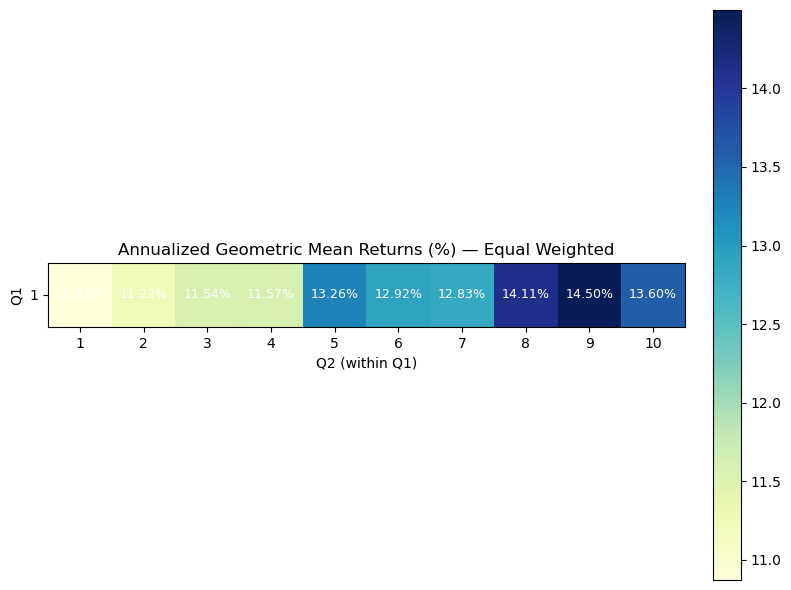

In [49]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=True,
    portrets_wide=ew_portrets_raw
)

In [27]:
ew_actual_mean_grid

,1,2,3
1,11.407983,12.896074,14.040346


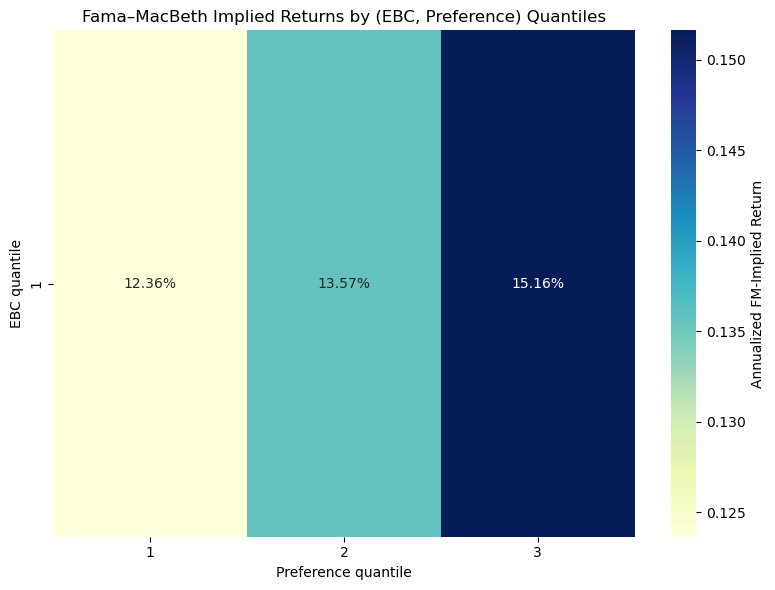

In [28]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2)

## turnover

In [29]:
# ── Portfolio Turnover (Cap Weighted) ─────────────────────────────────────
# Turnover = % of stocks that left each cell at each quarterly rebalancing.
# Stock membership is determined by beta sorts (identical for CW and EW).

members_ew = ew_results["members"].copy()
m = members_ew.reset_index()

# Identify the rebalancing date = first trading date of each quarter
m['period'] = m['date'].dt.to_period('Q')
first_date_per_period = m.groupby('period')['date'].min()
m_first = m[m['date'].isin(first_date_per_period.values)]

portfolio_names = {
    (1,1): "High Preference",
    (1,2): "Mid Preference",
    (1,3): "Low Preference"
    
}

In [30]:
period = start_date[:4] + '_2024'

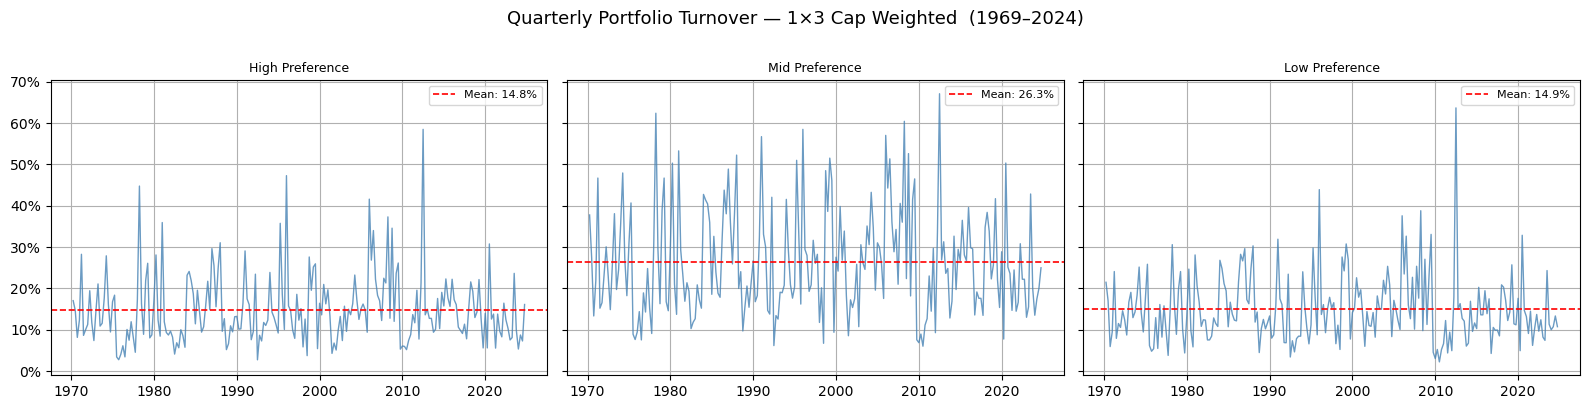

In [31]:
turnover_dict_cw = {}

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_first[(m_first['q1'] == q1) & (m_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)

        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers

        turnover_dict_cw[portfolio_names[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_cw = pd.DataFrame(turnover_dict_cw)

# ── Plot: 1x3 grid (three preference buckets) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, col in zip(axes.flatten(), turnover_cw.columns):
    avg = turnover_cw[col].mean()
    ax.plot(turnover_cw.index, turnover_cw[col], color='steelblue', linewidth=1, alpha=0.8)
    ax.axhline(avg, color='red', linestyle='--', linewidth=1.2, label=f"Mean: {avg:.1%}")
    ax.set_title(col, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    f"Quarterly Portfolio Turnover — {n_q1}×{n_q2} Cap Weighted  ({period.replace('_', '–')})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

In [32]:

# ── Average turnover summary table ─────────────────────────────────────────
avg_to_cw = pd.DataFrame({
    "Avg Quarterly Turnover": turnover_cw.mean(),
    "Annualized Turnover":    turnover_cw.mean() * 4,
}).round(4)

print("Average Turnover by Portfolio Cell (Cap Weighted):")
display(avg_to_cw)

Average Turnover by Portfolio Cell (Cap Weighted):


,Avg Quarterly Turnover,Annualized Turnover
High Preference,0.1483,0.5933
Mid Preference,0.2632,1.0528
Low Preference,0.1493,0.5973


# <span style="color:red"> Transaction Costs — Quantile Portfolios </span>

**Formula (Invesco):** `TC = 2 × Turnover × 0.0005`

| Term | Meaning |
|---|---|
| `Turnover` | Fraction of holdings that *exit* a cell at each quarterly rebalancing |
| `0.0005` | One-way cost per dollar traded (5 bps: bid-ask spread + execution) |
| `× 2` | Round-trip: pay the spread to **sell** exiting stocks **and** to **buy** replacements |

Rebalancing is **quarterly**, so the cost is a one-time deduction applied in the **first month** of each new quarter. Non-rebalancing months are unaffected.

> To change the cost assumption, adjust `ONE_WAY_COST` below.

In [50]:
ONE_WAY_COST = 0.005  # 5 bps per side — change here to update everything below

# ── Step 1: EW turnover (from member assignments) ─────────────────────────
# Turnover is identical for EW and CW since they share the same beta sorts / membership
members_ew = ew_results["members"].copy()
m_ew = members_ew.reset_index()
m_ew['period'] = m_ew['date'].dt.to_period('Q')
first_date_per_period_ew = m_ew.groupby('period')['date'].min()
m_ew_first = m_ew[m_ew['date'].isin(first_date_per_period_ew.values)]

# Dynamic names derived from portrets_wide column order (after rename)
_ew_cols = list(ew_results["portrets_wide"].columns)
portfolio_names_ew = {
    (q1, q2): _ew_cols[(q1 - 1) * n_q2 + (q2 - 1)]
    for q1 in range(1, n_q1 + 1)
    for q2 in range(1, n_q2 + 1)
}

turnover_dict_ew = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_ew_first[(m_ew_first['q1'] == q1) & (m_ew_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_ew[portfolio_names_ew[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_ew = pd.DataFrame(turnover_dict_ew)
turnover_ew_q = turnover_ew.copy()
turnover_ew_q.index = pd.DatetimeIndex(turnover_ew_q.index).to_period('Q')

# ── Step 2: Helper — map quarterly TC to first monthly return of each quarter ──
def build_tc_monthly(gross_df, turnover_q_df, one_way_cost):
    monthly_quarters = gross_df.index.to_period('Q')
    first_month_of_quarter = {}
    for date, q in zip(gross_df.index, monthly_quarters):
        if q not in first_month_of_quarter:
            first_month_of_quarter[q] = date
    tc = pd.DataFrame(0.0, index=gross_df.index, columns=gross_df.columns)
    for col in turnover_q_df.columns:
        if col not in tc.columns:
            continue
        for q_period, to_val in turnover_q_df[col].items():
            if q_period in first_month_of_quarter and not np.isnan(to_val):
                tc.loc[first_month_of_quarter[q_period], col] = 2 * to_val * one_way_cost
    return tc

# ── Step 3: Apply TC to both EW and CW portfolios ─────────────────────────
ew_gross = ew_results['portrets_wide'].copy()
#cw_gross = cw_results['portrets_wide'].copy()

ew_tc = build_tc_monthly(ew_gross, turnover_ew_q, ONE_WAY_COST)
#cw_tc = build_tc_monthly(cw_gross, turnover_ew_q, ONE_WAY_COST)

ew_net = ew_gross - ew_tc
#cw_net = cw_gross - cw_tc

print(f"One-way cost : {ONE_WAY_COST*10_000:.1f} bps  |  Round-trip per 100% turnover: {2*ONE_WAY_COST*100:.2f}%")
print(f"\nMean quarterly TC per EW portfolio (bps):")
print((ew_tc[ew_tc > 0].mean() * 10_000).round(2).to_string())

One-way cost : 50.0 bps  |  Round-trip per 100% turnover: 1.00%

Mean quarterly TC per EW portfolio (bps):
Q1_Q1     21.05
Q1_Q2     44.40
Q1_Q3     54.49
Q1_Q4     58.32
Q1_Q5     61.79
Q1_Q6     61.75
Q1_Q7     58.99
Q1_Q8     55.34
Q1_Q9     46.22
Q1_Q10    22.64


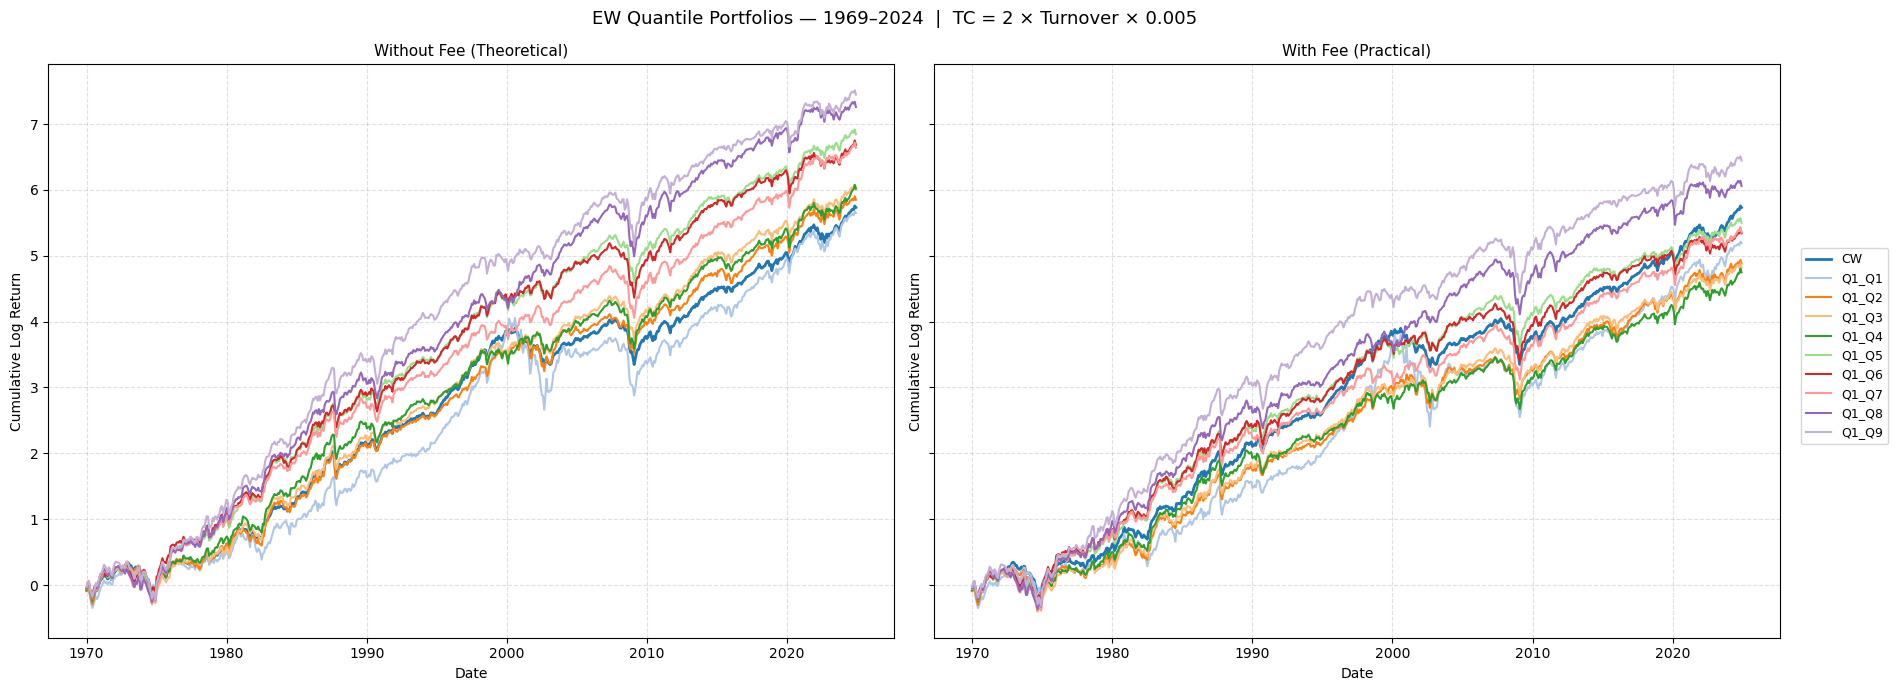

In [51]:
# ── Gross vs Net side-by-side (log cumulative returns) ────────────────────
# Left  = Without fee (theoretical)  |  Right = With fee (practical)

palette = plt.cm.tab20.colors
bench_color = palette[0]
port_colors = palette[1:10]

port_cols = list(ew_gross.columns)

bench = ew_complete_df['CW'].dropna()
bench_logcum = np.log1p(bench).cumsum()

def plot_gross_net_side_by_side(gross_df, net_df, bench_logcum, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, df, subtitle in zip(axes,
                                [gross_df, net_df],
                                ["Without Fee (Theoretical)", "With Fee (Practical)"]):
        ax.plot(bench_logcum.index, bench_logcum.values,
                color=bench_color, linewidth=2, label='CW')
        for col, color in zip(port_cols, port_colors):
            lc = np.log1p(df[col].dropna()).cumsum()
            ax.plot(lc.index, lc.values, color=color, linewidth=1.5, label=col)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Log Return")
        ax.grid(True, linestyle='--', alpha=0.4)

    # Single shared legend to the right of both panels
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=1, fontsize=9,
               bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_gross_net_side_by_side(
    ew_gross, ew_net, bench_logcum,
    f"EW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

In [35]:
# ── Summary: Gross vs Net annualized geometric mean returns ───────────────
def tc_summary(gross_df, net_df, tc_df, label):
    rows = []
    for col in gross_df.columns:
        ann_gross = (1 + np.expm1(np.log1p(gross_df[col].dropna()).mean())) ** 12 - 1
        ann_net   = (1 + np.expm1(np.log1p(net_df[col].dropna()).mean())) ** 12 - 1
        avg_ann_tc = tc_df[col][tc_df[col] > 0].mean() * 4  # 4 quarters/year
        rows.append({
            "Portfolio": col.replace("EBC_", "").replace("_", " "),
            "Gross Ann.": f"{ann_gross:.2%}",
            "Net Ann.":   f"{ann_net:.2%}",
            "TC Drag (bps)": f"{(ann_gross - ann_net)*10_000:.1f}",
            "Avg Ann. TC (bps)": f"{avg_ann_tc*10_000:.1f}",
        })
    df = pd.DataFrame(rows).set_index("Portfolio")
    print(f"\n{'─'*60}")
    print(f"  {label}  |  {ONE_WAY_COST*10_000:.0f}bps/side  |  Formula: 2 × Turnover × {ONE_WAY_COST}")
    print(f"{'─'*60}")
    display(df)

tc_summary(ew_gross, ew_net, ew_tc, "EW Quantile Portfolios")


────────────────────────────────────────────────────────────
  EW Quantile Portfolios  |  5bps/side  |  Formula: 2 × Turnover × 0.0005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref,11.41%,11.34%,6.5,5.9
Mid Pref,12.90%,12.78%,11.7,10.5
Low Pref,14.04%,13.97%,6.7,6.0


In [36]:
'''
save_dir = DATA_PROCESSED_DIR / 'monthly'
ew_results['portrets_wide'].to_csv(save_dir / f"monthly_{period}_ebc_1x3_ew_quantile_returns.csv")
print(f"Saved: monthly_{period}_ebc_1x3_ew_quantile_returns.csv")
'''

Saved: monthly_1969_2024_ebc_1x3_ew_quantile_returns.csv
